<a href="https://colab.research.google.com/github/fernandomartinarencibia/xbd-damage-classification/blob/main/damage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

# Clasificación de daños en edificios tras desastres naturales con imágenes satelitales (xBD)

**Proyecto en equipo** · Grado en Ingeniería Informática · Universidad Carlos III de Madrid (2025–2026)

Este notebook entrena dos redes convolucionales que clasifican el nivel de daño de cada edificio (sin daño, daño menor, daño mayor o destruido) a partir de las imágenes satelitales tomadas antes y después de un desastre natural.

**Resumen**

- **Datos:** 61.171 edificios de entrenamiento, 8.495 de validación y 22.222 de test del dataset xBD. El 83 % de los edificios de entrenamiento no tiene daños, así que el desbalanceo es la principal dificultad.
- **Entrada:** los parches de 64×64 de antes y después del desastre se apilan en un tensor de 6 canales (fusión temprana), para que la red compare los dos estados del edificio.
- **Modelos:** una CNN propia entrenada desde cero y una ResNet-18 preentrenada en ImageNet, adaptada a 6 canales.
- **Desbalanceo:** entropía cruzada ponderada por clase y selección del modelo por macro-F1.
- **Eficiencia:** los parches se preprocesan una vez y se guardan en caché, de modo que cada época solo lee de memoria (unos 3 minutos por modelo con GPU).

| Modelo | Macro-F1 en validación (mejor época) | Macro-F1 en validación (media de las 10 últimas épocas) |
| :--- | :---: | :---: |
| CNN propia | 0,450 (época 2) | 0,41 |
| ResNet-18 (fine-tuning, 6 canales) | 0,438 (época 4) | 0,42 |

En el conjunto de test oculto (competición de la asignatura en Codabench), el macro-F1 fue de **0,31** con la CNN propia y **0,33** con ResNet-18, y el equipo quedó **5.º de la clase**. El análisis completo está en la sección 8.

**Contenido:** 1. El problema y los datos · 2. Carga y visualización · 3. Preprocesado, caché y data augmentation · 4. CNN propia · 5. Entrenamiento y evaluación · 6. Fine-tuning de ResNet-18 · 7. Predicciones sobre test · 8. Resultados y conclusiones

**Ejecución:** los datos no se incluyen en el repositorio (ver sección 2). Se recomienda GPU. La primera ejecución genera la caché de parches en `data/xBD_UC3M_cache`.

**Autoría:** el esqueleto del notebook (la clase `xBDDataset`, las transformaciones `ToTensor` y `Normalize` y las funciones base de entrenamiento y test) lo proporcionó la asignatura. La fusión de 6 canales, las dos arquitecturas, la adaptación de ResNet-18, la data augmentation emparejada, la ponderación de clases, la caché de parches y el análisis de resultados son trabajo del equipo.

## 1. El problema y los datos

La respuesta ante un desastre natural necesita saber con rapidez qué edificios están dañados para priorizar la ayuda y los rescates. La evaluación presencial es lenta y peligrosa, así que el objetivo es automatizarla con imágenes de satélite. Cada edificio se clasifica en una escala ordinal de cuatro niveles:

- **Sin daño (0):** sin signos visibles de daños estructurales, en el tejado o marcas de quemaduras.
- **Daño menor (1):** parcialmente quemado, rodeado de agua, con elementos del tejado ausentes o grietas visibles.
- **Daño mayor (2):** colapso parcial de paredes o tejado, o estructura seriamente comprometida.
- **Destruido (3):** estructura calcinada, completamente colapsada o desaparecida.

**Dataset.** [xBD](https://arxiv.org/abs/1911.09296) (Gupta et al., 2019) es uno de los mayores conjuntos de datos de evaluación de daños en edificios: imágenes de alta resolución (menos de 0,8 m por píxel) de 19 desastres en todo el mundo (terremotos, inundaciones, incendios, huracanes y tsunamis), con pares de imágenes de antes y después y el polígono de cada edificio. Este proyecto usa un subconjunto proporcionado por la asignatura, con imágenes de 1024×1024 píxeles de las que se extrae un parche de 64×64 por edificio:

| Conjunto | Edificios |
| :--- | ---: |
| Entrenamiento | 61.171 |
| Validación | 8.495 |
| Test (etiquetas no públicas) | 22.222 |

## 2. Carga y visualización de los datos

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
import random
import numpy.random as npr
from natsort import natsorted
import json
import cv2
import tifffile
from shapely.wkt import loads
from shapely.geometry import Polygon

# Semillas fijas para la reproducibilidad
random.seed(42)
npr.seed(42)
torch.manual_seed(42)

import warnings
warnings.filterwarnings("ignore")

plt.ion()   # modo interactivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


**Ubicación de los datos.** El dataset no se incluye en el repositorio. El notebook espera encontrarlo descomprimido en `./data/xBD_UC3M`, con la estructura `{train,val,test}/<desastre>/{images,labels}`. El dataset completo está disponible en [xView2](https://www.xview2.org/). Las dos celdas siguientes solo son necesarias la primera vez en Google Colab, para copiar el zip desde Google Drive y descomprimirlo.

In [4]:
# Solo en Google Colab: montar Google Drive y copiar el zip del dataset
# from shutil import copyfile
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# copyfile('/content/drive/MyDrive/xBD_UC3M.zip', './xBD_UC3M.zip')

In [5]:
# Solo la primera vez: descomprimir el dataset en ./data
# import zipfile
# with zipfile.ZipFile('./xBD_UC3M.zip', 'r') as zip_ref:
#     zip_ref.extractall('./data')

In [6]:
DATA_DIR  = 'data/xBD_UC3M'         # dataset original
CACHE_DIR = 'data/xBD_UC3M_cache'   # caché de parches preprocesados (sección 3)

### Clase `xBDDataset`

`xBDDataset` (proporcionada por la asignatura) lee los pares de imágenes de antes y después y sus anotaciones en JSON. En lugar de trabajar con la imagen completa de 1024×1024, localiza el polígono de cada edificio y extrae un parche de 64×64 centrado en él. Las imágenes se leen bajo demanda en `__getitem__`, lo que evita cargar todo el dataset en memoria.

In [7]:
# Clase base proporcionada por la asignatura
class xBDDataset(Dataset):
    def __init__(self, data_dir, split=['train'], patch_size=64, transform=None, max_size=0):
        self.data_dir = data_dir
        self.split = split
        self.patch_size = patch_size
        self.transform = transform
        self.max_size = max_size

        self.image_pre_files = []
        self.image_post_files = []
        self.label_pre_files = []
        self.label_post_files = []
        for s in split:
            disaster_dirs = os.listdir(os.path.join(data_dir, s))

            for d in disaster_dirs:
                image_files = os.listdir(os.path.join(data_dir, s, d, 'images'))
                labels_files = os.listdir(os.path.join(data_dir, s, d, 'labels'))
                self.image_pre_files.append(natsorted([os.path.join(data_dir, s, d, 'images', f) \
                                        for f in image_files if 'pre' in f]))
                self.image_post_files.append(natsorted([os.path.join(data_dir, s, d, 'images', f) \
                                        for f in image_files if 'post' in f]))
                self.label_pre_files.append(natsorted([os.path.join(data_dir, s, d, 'labels', f) \
                                        for f in labels_files if 'pre' in f]))
                self.label_post_files.append(natsorted([os.path.join(data_dir, s, d, 'labels', f) \
                                        for f in labels_files if 'post' in f]))
        self.image_pre_files = natsorted(np.hstack(self.image_pre_files))
        self.image_post_files = natsorted(np.hstack(self.image_post_files))
        self.label_pre_files = natsorted(np.hstack(self.label_pre_files))
        self.label_post_files = natsorted(np.hstack(self.label_post_files))

        print(split)
        self.damage_classes = {
            'no-damage': 0,
            'minor-damage': 1,
            'major-damage': 2,
            'destroyed': 3
        }

        self.patches = []
        self.patch_labels = []
        self._get_patches_data()
        self._print_class_distribution()

    def _process_image(self, idx):
        image_pre = tifffile.imread(self.patch_image_pre[idx])
        if image_pre.shape[:2] != (1024, 1024):
            image_pre = cv2.resize(image_pre, (1024, 1024))

        image_post = tifffile.imread(self.patch_image_post[idx])
        if image_post.shape[:2] != (1024, 1024):
            image_post = cv2.resize(image_post, (1024, 1024))

        return image_pre, image_post #, mask_pre

    def _create_mask(self, label_path):
        mask = np.zeros((1024, 1024), dtype=np.uint8)

        try:
            with open(label_path, 'r') as f:
                data = json.load(f)

            if 'features' in data and 'xy' in data['features']:
                features = data['features']['xy']

                for feature in features:
                    if 'wkt' in feature:
                        try:
                            geom = loads(feature['wkt'])
                            if isinstance(geom, Polygon) and geom.is_valid:
                                coords = np.array(geom.exterior.coords, dtype=np.int32)
                                cv2.fillPoly(mask, [coords], 1)
                        except:
                            continue
        except:
            pass

        return mask

    def _get_patches_data(self):
        num_files = len(self.image_pre_files)
        self.patch_pre = []
        self.patch_post = []
        self.label_pre = []
        self.label_post = []
        self.label_post_path = []
        self.patch_image_pre = []
        self.patch_image_post = []

        for n in np.arange(num_files):
            label_pre_path = self.label_pre_files[n]
            label_post_path = self.label_post_files[n]

            with open(label_pre_path, 'r') as f_pre, open(label_post_path, 'r') as f_post:
                data_pre = json.load(f_pre)
                data_post = json.load(f_post)

                if 'features' in data_post and 'xy' in data_post['features']:
                    features_post = data_post['features']['xy']

                    for feature in features_post:
                        if 'wkt' in feature and 'properties' in feature:
                            props = feature['properties']
                            if props.get('feature_type') == 'building':
                                damage_type = props.get('subtype', 'no-damage')

                                if damage_type in self.damage_classes or damage_type == -1:
                                    self.patch_pre.append(feature['wkt'])
                                    self.patch_post.append(feature['wkt'])
                                    self.label_pre.append(0) # No damage before the event
                                    self.label_post.append(self.damage_classes[damage_type] if damage_type in self.damage_classes else -1)
                                    self.label_post_path.append(label_post_path)
                                    self.patch_image_pre.append(self.image_pre_files[n])
                                    self.patch_image_post.append(self.image_post_files[n])

        if self.max_size > 0:
            new_dataset_size = self.max_size
            idx = np.random.RandomState(seed=42).permutation(range(len(self.patch_pre)))
            self.patch_pre = np.array(self.patch_pre)[idx[0:new_dataset_size]]
            self.patch_post = np.array(self.patch_post)[idx[0:new_dataset_size]]
            self.label_pre = np.array(self.label_pre)[idx[0:new_dataset_size]]
            self.label_post = np.array(self.label_post)[idx[0:new_dataset_size]]
            self.label_post_path = np.array(self.label_post_path)[idx[0:new_dataset_size]]
            self.patch_image_pre = np.array(self.patch_image_pre)[idx[0:new_dataset_size]]
            self.patch_image_post = np.array(self.patch_image_post)[idx[0:new_dataset_size]]

    def _extract_patch(self, image, mask, wkt_str):
        geom = loads(wkt_str)
        if isinstance(geom, Polygon) and geom.is_valid:
            coords = np.array(geom.exterior.coords, dtype=np.int32)

            x_min, y_min = coords.min(axis=0)
            x_max, y_max = coords.max(axis=0)

            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2

            half_size = self.patch_size // 2

            x1 = max(0, center_x - half_size)
            y1 = max(0, center_y - half_size)
            x2 = min(image.shape[1], center_x + half_size)
            y2 = min(image.shape[0], center_y + half_size)

            patch = image[y1:y2, x1:x2]
            if mask is not None:
                mask_patch = mask[y1:y2, x1:x2]
            else:
                mask_patch = None

            if patch.shape[0] > 0 and patch.shape[1] > 0:
                patch = cv2.resize(patch, (self.patch_size, self.patch_size))
                if mask_patch is not None:
                    mask_patch = cv2.resize(mask_patch, (self.patch_size, self.patch_size))
        else:
            patch = np.zeros((self.patch_size, self.patch_size, image.shape[-1]))
            mask_patch = np.zeros((self.patch_size, self.patch_size))
        return patch, mask_patch

    def _print_class_distribution(self):
        class_counts = {}
        for label in self.label_post:
            class_counts[label] = class_counts.get(label, 0) + 1

        if 'test' not in self.split:
            class_names = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
            total_count = []
            for i, name in enumerate(class_names):
                count = class_counts.get(i, 0)
                total_count.append(count)
                print(f'{name}: {count}')
        print('Número total de parches de edificios encontrados: '+str(len(self.label_post)))

    def __len__(self):
        return len(self.patch_post)

    def __getitem__(self, idx):
        # Images (pre-, post-) and mask (pre-)
        # print(self.patch_image_pre[idx])
        image_pre, image_post = self._process_image(idx)
        image_pre = image_pre / 255.0
        image_post = image_post / 255.0

        mask = self._create_mask(self.label_post_path[idx])

        patch_pre, _ = self._extract_patch(image_pre, mask, self.patch_post[idx])
        patch_post, mask_patch = self._extract_patch(image_post, mask, self.patch_post[idx])

        label_pre = self.label_pre[idx]
        label_post = self.label_post[idx]

        sample = {'patch_pre': patch_pre,
                  'patch_post': patch_post,
                  'mask_patch': mask_patch,
                  'label_pre': label_pre,
                  'label_post': label_post,
                  'idx': idx}
        if self.transform:
            sample = self.transform(sample)
        return sample

In [8]:
patch_size = 64
train_dataset = xBDDataset(DATA_DIR, ['train'], patch_size=patch_size)

['train']
no-damage: 50928
minor-damage: 4659
major-damage: 2357
destroyed: 3227
Número total de parches de edificios encontrados: 61171


Imágenes completas (1024×1024) de antes y después de un evento elegido al azar:

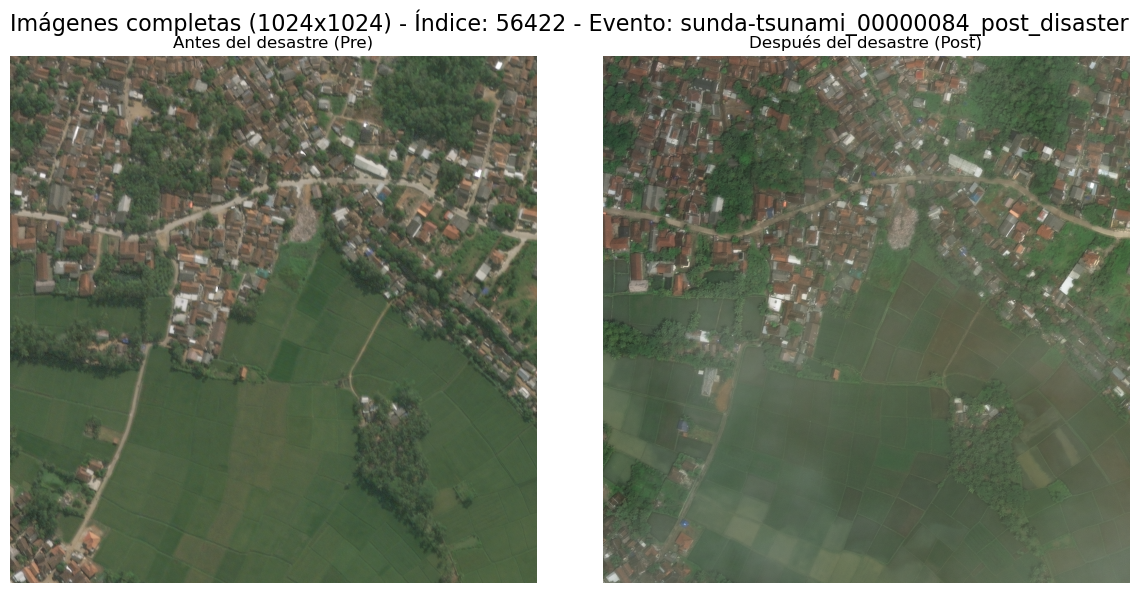

In [9]:
# Elegimos un índice aleatorio
idx = np.random.randint(0, len(train_dataset))

# Obtenemos las imágenes completas originales usando la función interna
image_pre_full, image_post_full = train_dataset._process_image(idx)
event = train_dataset.label_post_path[idx].split('/')[-1][:-5]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Imágenes completas (1024x1024) - Índice: {idx} - Evento: {event}", fontsize=16)

axes[0].imshow(image_pre_full)
axes[0].set_title("Antes del desastre (Pre)")
axes[0].axis('off')

axes[1].imshow(image_post_full)
axes[1].set_title("Después del desastre (Post)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Cada muestra es un diccionario con el parche previo (`patch_pre`), el posterior (`patch_post`), la máscara del edificio (`mask_patch`, que no se usa) y la etiqueta de daño (`label_post`, de 0 a 3). El esqueleto de la asignatura solo usaba el parche posterior; este proyecto usa **los dos**, ya que comparar el antes y el después es la forma más directa de detectar el daño.

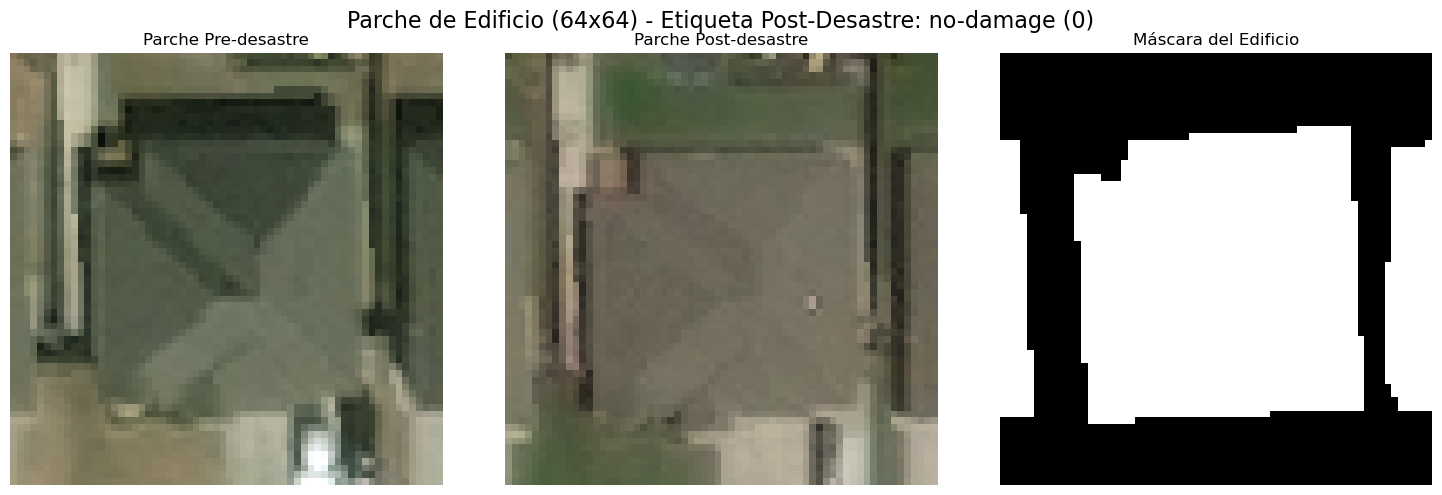

In [10]:
# Elegimos un índice aleatorio
idx = np.random.randint(0, len(train_dataset))

# Obtenemos un ejemplo procesado directamente desde el método __getitem__
sample = train_dataset[idx]

patch_pre = sample['patch_pre']
patch_post = sample['patch_post']
mask_patch = sample['mask_patch']
label_post = sample['label_post']

# Mapeo inverso de las clases de daño para la visualización
inverse_damage_classes = {v: k for k, v in train_dataset.damage_classes.items()}
damage_text = inverse_damage_classes[label_post]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Parche de Edificio (64x64) - Etiqueta Post-Desastre: {damage_text} ({label_post})", fontsize=16)

# Aseguramos que los valores estén en el rango correcto para matplotlib (0-255 o 0-1)
axes[0].imshow(patch_pre)
axes[0].set_title("Parche Pre-desastre")
axes[0].axis('off')

axes[1].imshow(patch_post)
axes[1].set_title("Parche Post-desastre")
axes[1].axis('off')

axes[2].imshow(mask_patch, cmap='gray')
axes[2].set_title("Máscara del Edificio")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. Preprocesado, caché y data augmentation

`ToTensor` convierte los parches de matrices NumPy (H×W×C) a tensores de PyTorch (C×H×W), y `Normalize` normaliza el parche posterior con la media y la desviación típica de ImageNet. Ambas transformaciones se aplican una sola vez, al generar la caché.

In [11]:
class ToTensor(object):
    """Convertimos ndarrays de la muestra en tensores."""

    def __call__(self, sample):
        image_pre, image, label = sample['patch_pre'], sample['patch_post'], sample['label_post']

        # Cambiamos los ejes
        # numpy image: H x W x C
        # torch image: C X H X W
        image_pre = image_pre.transpose((2, 0, 1))
        image_pre = torch.from_numpy(image_pre.astype(np.float32))

        image = image.transpose((2, 0, 1))
        image = torch.from_numpy(image.astype(np.float32))

        label=torch.tensor(label,dtype=torch.long)

        sample = {'patch_pre': image_pre,
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': label,
                  'idx': sample['idx']}
        return sample


class Normalize(object):
    """Normalizamos los datos restando la media y dividiendo por las desviaciones típicas.

    Args:
        mean_vec: El vector con las medias.
        std_vec: el vector con las desviaciones típicas.
    """

    def __init__(self, mean,std):

        assert len(mean)==len(std),'Length of mean and std vectors is not the same'
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image = sample['patch_post']
        c, h, w = image.shape
        assert c==len(self.mean), 'Length of mean and image is not the same'
        dtype = image.dtype
        mean = torch.as_tensor(self.mean, dtype=dtype, device=image.device)
        std = torch.as_tensor(self.std, dtype=dtype, device=image.device)
        image.sub_(mean[:, None, None]).div_(std[:, None, None])

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample

### Caché de parches

`xBDDataset` vuelve a leer y recortar las imágenes TIFF de 1024×1024 para cada parche en cada época, lo que convierte la lectura de datos en el cuello de botella del entrenamiento. Por eso los parches se generan una sola vez y se guardan en disco como tensores. `CachedXBDDataset` los carga en memoria, así que cada época solo lee de RAM.

### Data augmentation emparejada

La augmentation tiene que respetar que las dos imágenes muestran el mismo edificio:

- **Transformaciones geométricas, idénticas para las dos imágenes:** volteos horizontal y vertical y rotaciones de 0, 90, 180 o 270°. Las imágenes de satélite no tienen una orientación canónica, así que estas transformaciones generan ejemplos realistas.
- **Transformaciones fotométricas, independientes para cada imagen:** brillo y contraste, porque la iluminación y las condiciones de captura cambian entre las dos fechas.

La augmentation solo se aplica al conjunto de entrenamiento.

In [18]:
# Dataset ligero que carga patches preprocesados desde disco
# Una vez generada la caché, cada __getitem__ es una simple lectura de tensor en RAM
class CachedXBDDataset(Dataset):
    def __init__(self, cache_path, transform=None):
        data = torch.load(cache_path, weights_only=True)
        self.patches_pre  = data['patch_pre']   # [N, 3, 64, 64] float32 normalizado
        self.patches_post = data['patch_post']  # [N, 3, 64, 64] float32 normalizado
        self.labels       = data['label_post']  # [N] int64
        self.transform    = transform
        self.damage_classes = {'no-damage': 0, 'minor-damage': 1,
                               'major-damage': 2, 'destroyed': 3}

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pre  = self.patches_pre[idx].clone()
        post = self.patches_post[idx].clone()

        if self.transform is not None:
            pre, post = self.transform(pre, post)

        return {
            'patch_pre':  pre,
            'patch_post': post,
            'mask_patch': torch.zeros(64, 64),  # placeholder
            'label_pre':  torch.tensor(0, dtype=torch.long),
            'label_post': self.labels[idx],
            'idx': idx
        }


In [19]:
import torchvision.transforms.functional as TF
import random

class PairedAugmentation:
    """
    Augmentación para imágenes satelitales pareadas (pre/post desastre).
    - Transformaciones ESPACIALES: idénticas para pre y post
      (flip h/v + rotación 0/90/180/270°).
    - Transformaciones FOTOMÉTRICAS: independientes para cada imagen
      (brillo y contraste), ya que las condiciones de captura pueden diferir.
    Los tensores de entrada ya están normalizados con media/std de ImageNet.
    """
    def __init__(self, brightness=0.25, contrast=0.25, p_flip=0.5):
        self.brightness = brightness
        self.contrast   = contrast
        self.p_flip     = p_flip

    def __call__(self, patch_pre, patch_post):
        # --- Transformaciones espaciales: mismo azar para pre y post ---
        # Concatenamos en dim=0 para aplicar la misma op a los 6 canales
        combined = torch.cat([patch_pre, patch_post], dim=0)  # [6, 64, 64]

        if random.random() < self.p_flip:
            combined = TF.hflip(combined)
        if random.random() < self.p_flip:
            combined = TF.vflip(combined)

        # Rotación 0/90/180/270° — imágenes satelitales sin orientación canónica
        angle = random.choice([0, 90, 180, 270])
        if angle:
            combined = TF.rotate(combined, angle)

        patch_pre  = combined[:3].contiguous()
        patch_post = combined[3:].contiguous()

        # --- Transformaciones fotométricas: independientes por imagen ---
        # Operamos directamente sobre el tensor normalizado:
        #   brillo  → escala multiplicativa
        #   contraste → compresión hacia la media del canal
        for patch in [patch_pre, patch_post]:
            if random.random() < 0.8:
                # Brillo
                b = 1.0 + random.uniform(-self.brightness, self.brightness)
                patch.mul_(b)
            if random.random() < 0.8:
                # Contraste
                c = 1.0 + random.uniform(-self.contrast, self.contrast)
                mean = patch.mean(dim=(-2, -1), keepdim=True)
                patch.sub_(mean).mul_(c).add_(mean)
            # Clip para no salir del rango razonable del espacio normalizado
            patch.clamp_(-3.0, 3.0)

        return patch_pre, patch_post


In [20]:
# Preprocesado único: genera la caché de parches en disco.
# Después, el entrenamiento ya no vuelve a leer los .tif.
os.makedirs(CACHE_DIR, exist_ok=True)

_transform = transforms.Compose([
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in ['train', 'val', 'test']:
    cache_path = os.path.join(CACHE_DIR, f'{split}.pt')
    if os.path.exists(cache_path):
        print(f'{split}: caché ya existe, saltando.')
        continue
    print(f'Procesando {split}...')
    ds = xBDDataset(DATA_DIR, [split], patch_size=64, transform=_transform)
    all_pre, all_post, all_labels = [], [], []
    for i in range(len(ds)):
        s = ds[i]
        all_pre.append(s['patch_pre'])
        all_post.append(s['patch_post'])
        all_labels.append(s['label_post'])
        if (i+1) % 1000 == 0:
            print(f'  {i+1}/{len(ds)}')
    torch.save({
        'patch_pre':  torch.stack(all_pre),
        'patch_post': torch.stack(all_post),
        'label_post': torch.stack(all_labels)
    }, cache_path)
    print(f'{split}: {len(ds)} patches guardados -> {cache_path}')

print('Caché completada.')

train: caché ya existe, saltando.
val: caché ya existe, saltando.
test: caché ya existe, saltando.
Caché completada.


In [21]:
# Datasets cargados desde la caché.
# Solo el conjunto de entrenamiento recibe augmentation.
train_augmentation = PairedAugmentation(brightness=0.25, contrast=0.25, p_flip=0.5)

train_dataset = CachedXBDDataset(os.path.join(CACHE_DIR, 'train.pt'), transform=train_augmentation)
val_dataset   = CachedXBDDataset(os.path.join(CACHE_DIR, 'val.pt'))
test_dataset  = CachedXBDDataset(os.path.join(CACHE_DIR, 'test.pt'))

print(f'Train: {len(train_dataset)} muestras  (con augmentation)')
print(f'Val:   {len(val_dataset)} muestras')
print(f'Test:  {len(test_dataset)} muestras')

Train: 61171 muestras  (con augmentación)
Val:   8495 muestras
Test:  22222 muestras


### DataLoaders

Batches de 512 parches con 4 procesos de carga en paralelo. Solo se desordena el conjunto de entrenamiento. Debajo se muestra un batch de entrenamiento (parches posteriores, ya con augmentation).

Batch: (512, 3, 64, 64)


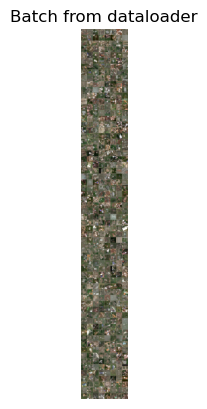

In [22]:
loader_kwargs = dict(batch_size=512, num_workers=4, pin_memory=True,
                     persistent_workers=True, prefetch_factor=2)

train_dataloader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_dataloader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_dataloader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)


def show_batch(sample_batched):
    """Muestra los parches posteriores de un batch, desnormalizados."""
    grid = utils.make_grid(sample_batched['patch_post'])
    grid = grid.numpy().transpose((1, 2, 0))
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    grid = np.clip(std * grid + mean, 0, 1)
    plt.imshow(grid)
    plt.title('Batch from dataloader')


sample_batched = next(iter(train_dataloader))
print('Batch:', tuple(sample_batched['patch_post'].shape))

plt.figure()
show_batch(sample_batched)
plt.axis('off')
plt.show()

## 4. CNN propia

`CustomNet` recibe el tensor de 6 canales y lo procesa con cuatro bloques convolucionales (Conv 3×3, BatchNorm, ReLU y MaxPool). Cada bloque duplica el número de filtros (de 32 a 256) y reduce la resolución a la mitad, de 64×64 a 4×4. Un global average pooling sustituye al aplanado, lo que reduce mucho los parámetros de la capa final y el riesgo de sobreajuste. Por último, una capa lineal produce las puntuaciones de las 4 clases.

In [23]:
class CustomNet(nn.Module):
    def __init__(self):
        super(CustomNet, self).__init__()

        # Bloque 1: in_channels=6 (imagen de entrada con 6 canales)
        self.block1 = nn.Sequential(
            nn.Conv2d(6, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Global Average Pooling en lugar de Flatten
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Capa de salida: 4 clases
        self.fc = nn.Linear(256, 4)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)          # (B, 256, 1, 1)
        x = x.flatten(1)         # (B, 256)
        x = self.fc(x)           # (B, 4)
        return x

Comprobación de dimensiones con un batch real: la entrada es `[B, 6, 64, 64]` y la salida, `[B, 4]`.

In [24]:
customNet = CustomNet() #Invocamos el constructor de la red (método init())
customNet.to(device) #Pasamos la red al device que estemos usando (gpu)
#Obtenemos un batch de datos y extraemos imágenes y etiquetas
data=next(iter(train_dataloader))
inputs_pre = data['patch_pre'].to(device).float()
inputs_post = data['patch_post'].to(device).float()
inputs = torch.cat([inputs_pre, inputs_post], dim=1)  # 3+3=6 canales
labels = data['label_post'].to(device)

batchSize = labels.shape
print('El tamaño del tensor que representa un batch de imágenes es {}'.format(inputs.shape))

#Lo pasamos por la red
with torch.set_grad_enabled(False):
    outputs = customNet(inputs)
    print('El tamaño del tensor de salida es {}'.format(outputs.shape))

El tamaño del tensor que representa un batch de imágenes es torch.Size([512, 6, 64, 64])
El tamaño del tensor de salida es torch.Size([512, 4])


## 5. Entrenamiento y evaluación

**Métrica.** Con un 83 % de edificios sin daño, la exactitud premiaría a un modelo que siempre predijera esa clase. Por eso se usa el **macro-F1**: el F1 de cada clase (media armónica de precisión y recall) promediado con el mismo peso para las cuatro clases. La matriz de confusión, normalizada por filas, muestra el recall de cada clase.

In [25]:
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Pérdida y optimización.** Entropía cruzada ponderada por la inversa de la frecuencia de cada clase, para que los errores en las clases minoritarias pesen más. SGD con momento 0,9 y un learning rate que se divide entre 10 cada 7 épocas.

In [26]:
# Pérdida ponderada por la inversa de la frecuencia de cada clase en entrenamiento
class_counts = torch.bincount(train_dataset.labels, minlength=4).float()  # [50928, 4659, 2357, 3227]
weights = 1.0 / class_counts
weights = (weights / weights.sum()) * len(class_counts)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# SGD con momento
optimizer_ft = optim.SGD(customNet.parameters(), lr=1e-2, momentum=0.9)

# El learning rate se divide entre 10 cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

**Bucle de entrenamiento.** En cada época se entrena con el conjunto de entrenamiento y se evalúa en validación. Las imágenes previa y posterior se concatenan en el eje de canales antes de entrar en la red. Se conservan los pesos de la época con mejor macro-F1 en validación y el historial de pérdida y F1 para dibujar las curvas de aprendizaje.

In [27]:
#Los parámetros de train_model son la red (model), el criterio (la loss),
# el optimizador, una estrategia de lr, y las épocas de entrenamiento
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, plot_confusion_matrix=True):

    #Fijamos semillas para maximizar reproducibilidad
    random.seed(42)
    npr.seed(42)
    torch.manual_seed(42)
    torch.backends.cudnn.benchmark = True  # Permite a cuDNN optimizar kernels para mayor rendimiento GPU

    since = time.time()

    numClasses = len(list(image_datasets['train'].damage_classes.keys()))

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0
    best_outputs = []
    best_labels = []

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    #Bucle de épocas de entrenamiento
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Cada época tiene entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Ponemos el modelo en modo entrenamiento
            else:
                model.eval()   # Ponemos el modelo en modo evaluación


            #Tamaño del dataset
            numSamples = dataset_sizes[phase]

            # Creamos las variables que almacenarán las salidas y las etiquetas
            outputs_m=np.zeros((numSamples,numClasses),dtype=np.float32)
            labels_m=np.zeros((numSamples,),dtype=int)
            running_loss = 0.0

            contSamples=0

            # Iteramos sobre los datos.
            for sample in dataloaders[phase]:
                    # --- EARLY FUSION: extraer pre y post y concatenar por canales ---
                patch_pre  = sample['patch_pre'].to(device)
                patch_post = sample['patch_post'].to(device)
                inputs = torch.cat([patch_pre, patch_post], dim=1)  # [B, 6, 64, 64]
                # --- FIN EARLY FUSION -
                labels = sample['label_post'].to(device)

                #Tamaño del batch
                batchSize = labels.shape[0]

                # Ponemos a cero los gradientes
                optimizer.zero_grad()

                # Paso forward
                # registramos operaciones solo en train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # backward y optimización solo en training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Sacamos estadísticas y actualizamos variables
                running_loss += loss.item() * inputs.size(0)

                #Aplicamos un softmax a la salida
                outputs=F.softmax(outputs.data,dim=1)
                outputs_m [contSamples:contSamples+batchSize,...]=outputs.cpu().numpy()
                labels_m [contSamples:contSamples+batchSize]=labels.cpu().numpy()
                contSamples+=batchSize

            #Actualizamos la estrategia de lr
            if phase == 'train':
                scheduler.step()

            #Loss acumulada en la época
            epoch_loss = running_loss / dataset_sizes[phase]

            #Calculamos Macro F1-score
            epoch_f1=f1_score(labels_m,np.argmax(outputs_m,axis=1),average='macro')

            print('{} Loss: {:.4f} Macro F1-score: {:.4f}'.format(
                phase, epoch_loss, epoch_f1))

            # Guardamos métricas en el historial
            history[phase + '_loss'].append(epoch_loss)
            history[phase + '_f1'].append(epoch_f1)

            # copia profunda del mejor modelo
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
                best_outputs = np.argmax(outputs_m,axis=1)
                best_labels = labels_m

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Macro F1-score: {:4f}'.format(best_f1))

    if plot_confusion_matrix:
        # Visualizamos la matriz de confusión
        cm=confusion_matrix(best_labels, best_outputs, normalize='true')
        #print(cm)
        #Vamos a mostrar en porcentajes en vez de probs
        ncmd=ConfusionMatrixDisplay(100*cm,display_labels=list(image_datasets['val'].damage_classes.keys()))
        ncmd.plot(xticks_rotation='vertical')
        plt.title('Normalized confusion matrix (%)')
        plt.show()

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history


In [28]:
image_datasets = {'train' : train_dataset, 'val': val_dataset, 'test': test_dataset}

dataloaders = {'train' : train_dataloader, 'val': val_dataloader, 'test': test_dataloader}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
class_names = list(image_datasets['train'].damage_classes.keys())


### Entrenamiento de la CNN propia (25 épocas)

Epoch 0/24
----------
train Loss: 0.9460 Macro F1-score: 0.4364
val Loss: 1.4585 Macro F1-score: 0.3873

Epoch 1/24
----------
train Loss: 0.8179 Macro F1-score: 0.5082
val Loss: 2.1512 Macro F1-score: 0.3996

Epoch 2/24
----------
train Loss: 0.7578 Macro F1-score: 0.5374
val Loss: 1.6537 Macro F1-score: 0.4503

Epoch 3/24
----------
train Loss: 0.7208 Macro F1-score: 0.5552
val Loss: 1.5126 Macro F1-score: 0.3938

Epoch 4/24
----------
train Loss: 0.7053 Macro F1-score: 0.5613
val Loss: 2.3368 Macro F1-score: 0.4055

Epoch 5/24
----------
train Loss: 0.6859 Macro F1-score: 0.5723
val Loss: 4.1830 Macro F1-score: 0.3645

Epoch 6/24
----------
train Loss: 0.6732 Macro F1-score: 0.5817
val Loss: 2.3589 Macro F1-score: 0.4079

Epoch 7/24
----------
train Loss: 0.6211 Macro F1-score: 0.6078
val Loss: 2.0126 Macro F1-score: 0.3993

Epoch 8/24
----------
train Loss: 0.6111 Macro F1-score: 0.6131
val Loss: 2.2681 Macro F1-score: 0.4125

Epoch 9/24
----------
train Loss: 0.6044 Macro F1-score

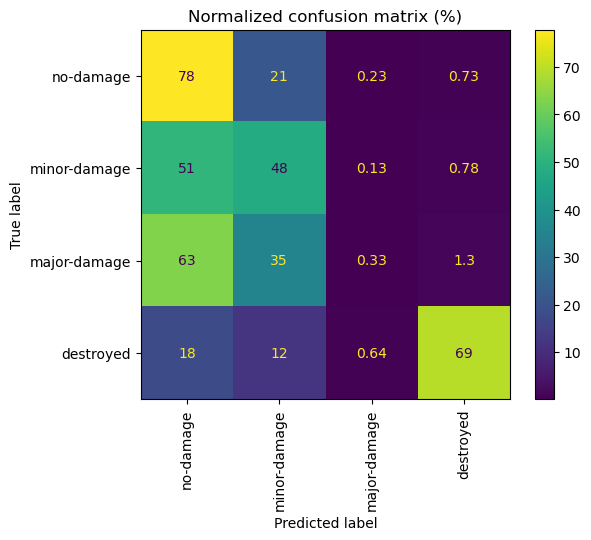

In [29]:
customNet, custom_history = train_model(customNet, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

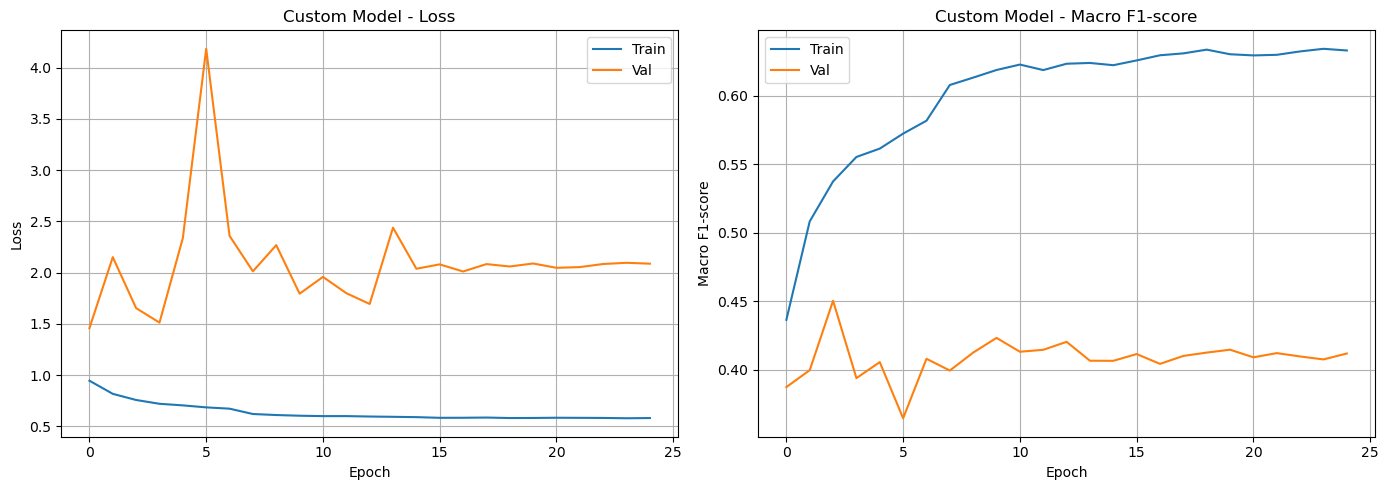

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(len(custom_history['train_loss']))

ax1.plot(epochs, custom_history['train_loss'], label='Train')
ax1.plot(epochs, custom_history['val_loss'], label='Val')
ax1.set_title('Custom Model - Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, custom_history['train_f1'], label='Train')
ax2.plot(epochs, custom_history['val_f1'], label='Val')
ax2.set_title('Custom Model - Macro F1-score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1-score')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Fine-tuning de ResNet-18

Se parte de una ResNet-18 preentrenada en ImageNet. Como la entrada tiene 6 canales en lugar de 3, la primera convolución se sustituye por una nueva de 6 canales en la que se copian los pesos RGB preentrenados, tanto en los canales de la imagen previa como en los de la posterior. Así, las dos imágenes se procesan desde el principio con los filtros aprendidos en ImageNet. La capa final se sustituye por un clasificador de 4 clases precedido de un dropout (p = 0,4) para frenar el sobreajuste.

In [31]:
import torchvision.models as models

# ---------------------------------------------------------------
# 1. Cargar ResNet18 con pesos preentrenados en ImageNet
# ---------------------------------------------------------------
resnet18 = models.resnet18(weights="DEFAULT")

# ---------------------------------------------------------------
# 2. Modificar la primera capa convolucional: 3 → 6 canales
#    ResNet18.conv1: Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
# ---------------------------------------------------------------
# Guardamos los pesos originales (3 canales RGB) antes de sustituir la capa
original_conv1_weights = resnet18.conv1.weight.data.clone()  # shape: [64, 3, 7, 7]

# Creamos una nueva conv1 con 6 canales de entrada y los mismos hiperparámetros
new_conv1 = nn.Conv2d(
    in_channels=6,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False  # igual que el original
)

# Inicializamos los pesos de la nueva capa con ceros para partir de un estado neutro
nn.init.zeros_(new_conv1.weight)

# CRÍTICO: Copiar los pesos RGB preentrenados a los primeros 3 canales (imagen "antes")
# y también a los 3 canales restantes (imagen "después").
# Esto preserva las características visuales ya aprendidas en ImageNet y proporciona
# una buena inicialización para los canales de la imagen post-desastre.
with torch.no_grad():
    new_conv1.weight[:, :3, :, :] = original_conv1_weights   # canales 0-2: imagen pre-desastre
    new_conv1.weight[:, 3:, :, :] = original_conv1_weights   # canales 3-5: imagen post-desastre

# Sustituimos la capa original por la nueva
resnet18.conv1 = new_conv1

# ---------------------------------------------------------------
# 3. Modificar la capa de salida (fc): 1000 → 4 clases
#    no-damage | minor-damage | major-damage | destroyed
# ---------------------------------------------------------------
num_ftrs = resnet18.fc.in_features  # 512 en ResNet18
num_classes = 4
# Dropout antes del clasificador para regularizar el overfitting severo
resnet18.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, num_classes)
)

# ---------------------------------------------------------------
# 4. Enviar el modelo al dispositivo (GPU si está disponible)
# ---------------------------------------------------------------
ftNet = resnet18.to(device)

print(f"Entrada: 6 canales  |  Salida: {num_classes} clases")
print(f"Parámetros totales: {sum(p.numel() for p in ftNet.parameters()):,}")


Entrada: 6 canales  |  Salida: 4 clases
Parámetros totales: 11,187,972


Optimizador para la nueva red: un learning rate menor (1e-3), adecuado para ajustar pesos ya preentrenados, y un weight decay de 1e-4. Se reutiliza la misma pérdida ponderada.

In [32]:
optimizer_ft = optim.SGD(ftNet.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

# El learning rate se divide entre 10 cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

### Entrenamiento de ResNet-18 (25 épocas)

Epoch 0/24
----------
train Loss: 1.0671 Macro F1-score: 0.4014
val Loss: 1.3236 Macro F1-score: 0.4178

Epoch 1/24
----------
train Loss: 0.7797 Macro F1-score: 0.5355
val Loss: 1.4370 Macro F1-score: 0.4260

Epoch 2/24
----------
train Loss: 0.7093 Macro F1-score: 0.5721
val Loss: 1.4225 Macro F1-score: 0.4330

Epoch 3/24
----------
train Loss: 0.6645 Macro F1-score: 0.5913
val Loss: 1.5281 Macro F1-score: 0.4320

Epoch 4/24
----------
train Loss: 0.6319 Macro F1-score: 0.6057
val Loss: 1.5139 Macro F1-score: 0.4375

Epoch 5/24
----------
train Loss: 0.6181 Macro F1-score: 0.6147
val Loss: 1.7139 Macro F1-score: 0.4252

Epoch 6/24
----------
train Loss: 0.5911 Macro F1-score: 0.6252
val Loss: 1.9405 Macro F1-score: 0.4322

Epoch 7/24
----------
train Loss: 0.5788 Macro F1-score: 0.6297
val Loss: 1.7122 Macro F1-score: 0.4223

Epoch 8/24
----------
train Loss: 0.5669 Macro F1-score: 0.6399
val Loss: 1.7482 Macro F1-score: 0.4179

Epoch 9/24
----------
train Loss: 0.5700 Macro F1-score

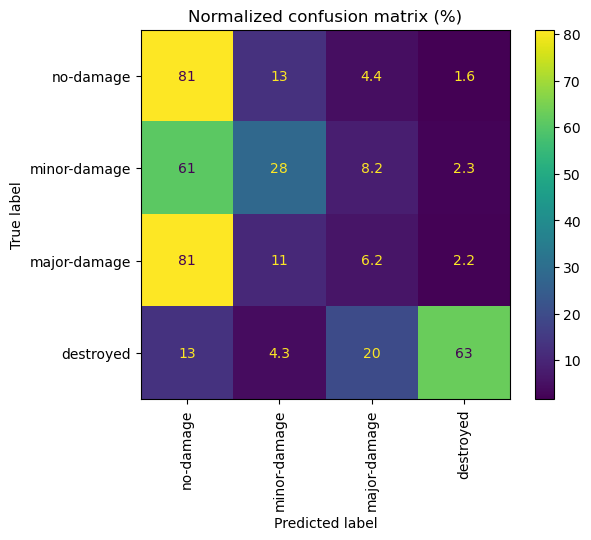

In [33]:
ftNet, ft_history = train_model(ftNet, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

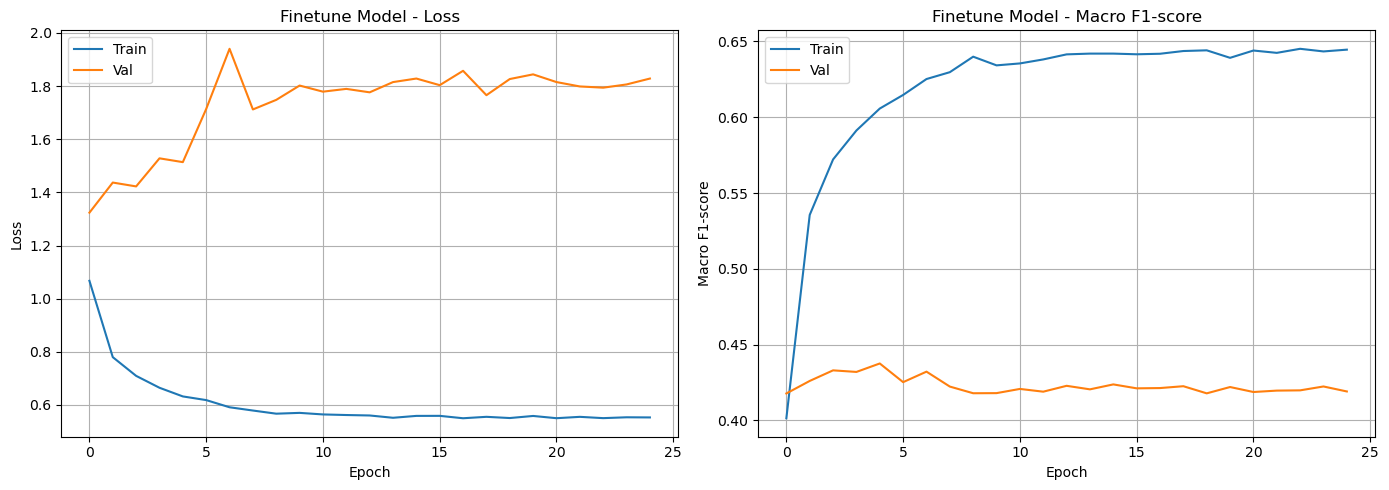

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(len(ft_history['train_loss']))

ax1.plot(epochs, ft_history['train_loss'], label='Train')
ax1.plot(epochs, ft_history['val_loss'], label='Val')
ax1.set_title('Finetune Model - Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, ft_history['train_f1'], label='Train')
ax2.plot(epochs, ft_history['val_f1'], label='Val')
ax2.set_title('Finetune Model - Macro F1-score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1-score')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Predicciones sobre test

Las etiquetas de test no son públicas. El resultado en test se obtuvo enviando, para cada modelo, la matriz de probabilidades de 22.222 × 4 (un edificio por fila, una clase por columna) a la competición de la asignatura en Codabench. Resultado: macro-F1 de 0,31 (CNN propia) y 0,33 (ResNet-18), 5.º puesto de la clase.

In [35]:
def test_model(model):
    """Devuelve la matriz de probabilidades [N, 4] para el conjunto de test."""
    numClasses = len(list(image_datasets['test'].damage_classes.keys()))
    model.eval()

    numSamples = len(test_dataset)
    outputs_m = np.zeros((numSamples, numClasses), dtype=np.float32)
    contSamples = 0

    for sample in test_dataloader:
        patch_pre  = sample['patch_pre'].to(device).float()
        patch_post = sample['patch_post'].to(device).float()
        inputs = torch.cat([patch_pre, patch_post], dim=1)  # [B, 6, 64, 64]
        batchSize = inputs.shape[0]

        with torch.no_grad():
            outputs = F.softmax(model(inputs), dim=1)
            outputs_m[contSamples:contSamples+batchSize, ...] = outputs.cpu().numpy()
            contSamples += batchSize

    return outputs_m

In [36]:
outputs_custom = test_model(customNet)
outputs_ft = test_model(ftNet)

Se guardan las predicciones en CSV y se empaquetan en un zip para el envío:

In [37]:
import csv

with open('output_custom.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_custom)


with open('output_ft.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_ft)

In [38]:
from zipfile import ZipFile

# Create a ZipFile Object
with ZipFile('./codabench_submission.zip', 'w') as zip_object:
   # Adding files that need to be zipped
   zip_object.write('./output_custom.csv')
   zip_object.write('./output_ft.csv')

## 8. Resultados y conclusiones

| Modelo | Macro-F1 val (mejor época) | Macro-F1 val (media 10 últimas épocas) | Recall sin daño | Recall daño menor | Recall daño mayor | Recall destruido |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| CNN propia | 0,450 (época 2) | 0,41 | 78 % | 48 % | 0,3 % | 69 % |
| ResNet-18 (6 canales) | 0,438 (época 4) | 0,42 | 81 % | 28 % | 6,2 % | 63 % |

Los recalls corresponden a la mejor época de cada modelo (matrices de confusión de las secciones 5 y 6).

| Modelo | Macro-F1 en test oculto (Codabench) |
| :--- | :---: |
| CNN propia | 0,31 |
| ResNet-18 (6 canales) | **0,33** |

El equipo quedó 5.º de la clase en la competición.

**Observaciones**

- **Los dos modelos rinden de forma muy parecida.** El mejor valor de la CNN propia es un pico aislado: las épocas vecinas rondan 0,39–0,40 y su pérdida de validación es muy inestable. En el tramo final, ResNet-18 es ligeramente superior y más estable (0,42 frente a 0,41), y en test también queda por delante (0,33 frente a 0,31).
- **El sobreajuste aparece pronto.** Ambos modelos alcanzan su mejor F1 en validación en las cinco primeras épocas. Después, el F1 de entrenamiento sigue subiendo hasta 0,63–0,64, mientras que el de validación se estanca en 0,41–0,42 y la pérdida de validación crece.
- **El daño mayor es el principal punto débil.** La CNN propia casi nunca predice esta clase (recall del 0,3 %) y la confunde sobre todo con «sin daño» (63 %) y «daño menor» (35 %). ResNet-18 la reconoce algo más (6,2 %). El daño menor también se confunde mucho con «sin daño». En cambio, los edificios destruidos se reconocen bien (63–69 %), porque su cambio visual es mucho más evidente.
- **La validación sobrestima el rendimiento.** El macro-F1 baja de 0,44–0,45 en la mejor época de validación a 0,31–0,33 en el test oculto. Parte de la diferencia se debe a elegir la época con el mismo conjunto de validación; el tamaño de la caída sugiere además que las imágenes de test son más difíciles o tienen otra distribución, algo que no se puede comprobar porque sus etiquetas son ocultas.

**Siguientes pasos:** focal loss o muestreo balanceado para las clases minoritarias, más regularización y augmentation, parches más grandes que incluyan contexto alrededor del edificio, backbones preentrenados en imágenes de teledetección (por ejemplo, [TorchGeo](https://torchgeo.readthedocs.io/)) y early stopping con paciencia en lugar de 25 épocas fijas.